## Esercizio 1  (esercizio 4 dell'esercitazione 7-8)
Si implementi una function *solve_nsis(A,B)* per il calcolo della soluzione di un generale sistema lineare $AX = B$, con $X, B$ matrici, che usi la fattorizzazione LU della matrice PA, per risolvere n sistemi lineari: aventi la stessa matrice dei coefficienti A e termine noto l'i-esima colonna della matrice B. 
Utilizzarla poi per il calcolo dell'inversa delle
matrici non singolari
$$
A=\left[
\begin{array}{ccc}
3 & 5 & 7\\
2 & 3 & 4\\
5 & 9 & 11
\end{array}
\right ], \qquad
A=\left[
\begin{array}{cccc}
1 & 2 & 3 & 4\\
2 & -4 & 6 & 8\\
-1 & -2 & -3 & -1\\
5 & 7 & 0 & 1
\end{array}
\right ],
$$
confrontando i risultati ottenuti con l'output
della funzione  *scipy.linalg.inv(A)*

Sfruttando la fattorizzazione PA=LU  di una delle matrici del punto precedente, calcolarne il determinante.

Dire sarebbe stato possibile calcolare la fattorizzazione A=LU delle due matrici del punto precedente (cioè utilizzare la fattorizzazione LU senza scambio di righe)

## Esercizio 2  (esercizio 6 dell'esercitazione 7-8)
Per valori di $n = 4 : 6 : 40$, si consideri il sistema lineare $A_n x = b$ con
$A_n$ matrice di Hankel di ordine $n$ di elementi
$$
a^{(n)}_{i,n+k-i}
=
\left \{
\begin{array}{ll}
2^k & \hbox{se} \ k > 0,\\
2^{1/(2-k)} & \hbox{se} \ k \leq 0,
\end{array}
\right .
\qquad
i = 1, ..., n, \ \  k = i + 1-n, ..., i,
$$
e $b$ scelto in modo che risulti $x = [1, 1, ..., 1]^T$. Si risolva tale sistema
con il metodo di fattorizzazione LU della matrice PA
e il metodo di fattorizzazione QR (Q,R  =scipy.linalg.qr(A)).
Calcolare gli errori relativi $\| \delta x \|_2/\|x\|_2$ da cui sono affette
le soluzioni calcolate con i due metodi e produrre, al variare di $n$, un
grafico in scala logaritmica ( matplotlib.plyplot.loglog) degli errori relativi calcolati. Che cosa si
osserva?

## Esercizio 3 (esercizio 8 dell'esercitazione 5-6)  
Si consideri lo sviluppo in serie dell'esponenziale $e^x=1+x+\frac{1}{2!}x^2+\frac{1}{3!}x^3+\cdots =\sum_{k=0}^\infty \frac{x^k}{k!} $. Si calcoli un'approssimazione dell'esponenziale troncando ad N=100 termini la serie, per valori di x che variano da -10 a 10 incluso. Si calcoli  per ogni valore di x l'errore relativo del valore approssimato rispetto al valore esatto, ottenuto mediante la funzione exp della libreria numpy. Cosa si osserva? Pensare ad un algoritmo più stabile ricordando che $e^{-x}=\frac{1}{e^{|x|}}$.

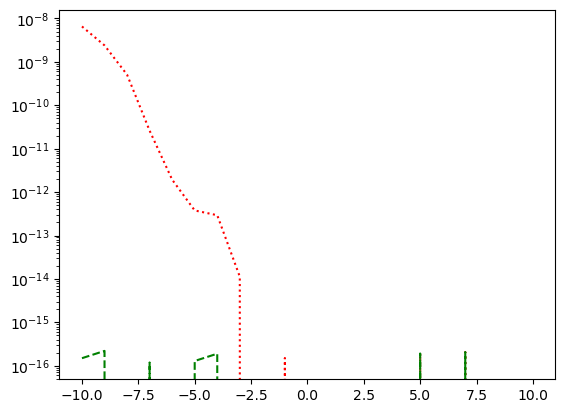

In [76]:
from scipy.special import factorial
import numpy as np
import matplotlib.pyplot as plt

k = np.arange(100)
x = np.arange(-10, 11.0)
serie = lambda range: np.array([np.sum([x**k / factorial(k)]) for x in range])
serie_inv = lambda range: 1 / np.array([np.sum([np.abs(x)**k / factorial(k)]) for x in range])
real = lambda x: np.exp(x)

stable = lambda x: np.r_[serie_inv(x[x < 0]),serie(x[x >= 0])]

err = lambda real, pert: np.abs(real - pert) / np.abs(real)
plt.semilogy(x, err(real(x), serie(x)), 'r:', x, err(real(x), stable(x)), 'g--')
plt.show()


## Esercizio 4 (Esercizio 6 esercitazione 5-6)

Assegnato il sistema lineare $Ax = b$, con
$$
A =
\left [
\begin{array}{ccc}
6 & 63 & 662.2\\
63 & 662.2 & 6967.8\\
662.2 & 6967.8 & 73393.5664
\end{array}
\right ], \qquad
b =
\left [
\begin{array}{c}
1.1\\
2.33\\
1.7
\end{array}
\right ]
$$
- trovare il vettore soluzione $x$ (usando la la fattorizzazione più opportuna);
- perturbare la matrice dei coefficienti della quantità
$$
\delta A =
0.01 \, \ast \,
\left [ \begin{array}{ccc}
1 & 0 & 0\\
0 & 0 & 0\\
0 & 0 & 0
\end{array}
\right ]
$$
quindi calcolare l'errore relativo sulla soluzione e confrontarlo con la
perturbazione relativa sui dati di ingresso. Cosa si osserva?

In [142]:
from scipy import linalg as splin
from SolveTriangular import *
from numpy.linalg import norm, eigvals 

def cho_solve(A, b):
    L = np.linalg.cholesky(A)
    return Usolve(np.transpose(L), Lsolve(L, b)) 

err_rel = lambda r, pert: norm(r - pert) / norm(r)
K = lambda A: norm(A) * norm(splin.inv(A))

A = np.array([[6 , 63 , 662.2],[63 , 662.2 , 6967.8],[662.2 , 6967.8 , 73393.5664]])
b = np.array([1.1, 2.33, 1.7])

#testo se la matrice è simmetrica
assert np.allclose(A, A.T)
#verifico che gli autovalori reali siano strettamente positivi 
assert all(np.r_[np.isreal(eigvals(A)), eigvals(A) > 0])

x = cho_solve(A, b)

delta_A = A.copy()
delta_A[0, 0] = delta_A[0, 0] + 0.01
delta_x = cho_solve(delta_A, b)

print(f'Errore del {err_rel(x, delta_x):.3%}')

print(f'Indice di Condizionamento: {K(A)}')

if K(A) > 10**3:
    print(f'Problema malcondizionato')

Errore del 99.951%
Indice di Condizionamento: 15598411658.985374
Problema malcondizionato


Uso cholesky poiche mi rendo conto che la matrice è simmetrica e definita positiva, infatti la trasposta e l'originaria sono le stesse, inoltre tutti gli autovalori della matrice sono reali e strettamente positivi

Nonostante la pertubazione dei dati sia molto bassa l'errore relativo della soluzione risulta altissimo poichè il problema in sè è malcondizionato avendo un K adirittura molto superiore al limite di condizionamento di matrici (di norma $10^3$) 